## **Car Prediction Project | EDA**
1. Import DataSet
2. EDA Review
3. Explore Categorical Features
4. Feature Engineering within Categorical Features
5. Explore Numerical Features
6. Feature Engineering within Numerical  Features

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder

In [2]:
data = pd.read_csv("../data/car_price_prediction.csv")

In [3]:
data.head(5)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


In [4]:
data.tail(5)

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4
19236,45813273,470,753,HYUNDAI,Sonata,2012,Sedan,Yes,Hybrid,2.4,186923 km,4.0,Automatic,Front,04-May,Left wheel,White,12


In [5]:
data.shape

(19237, 18)

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  str    
 13  Drive wheels      19237 non-null  str    
 14  Doors             19237 non-null  str    
 15  Wheel             19237 non-null  str    
 16  Color             19237 non-null  str    
 17  Airb

In [7]:
print(f"Name Of Features is : \n{data.columns.tolist()}")

Name Of Features is : 
['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year', 'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage', 'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color', 'Airbags']


In [8]:
# @Duplicates Values
print(f"Number of duplicated Rows before dropped : {data.duplicated().sum()}")
data.drop_duplicates(inplace= True)
print(f"Number of duplicated Rows After dropped : {data.duplicated().sum()}")

Number of duplicated Rows before dropped : 313
Number of duplicated Rows After dropped : 0


In [9]:
# @Types Of Variables
categoric_feat = [col for col in data.columns if data[col].dtypes == "str"]
numeric_feat = [col for col in data.columns if data[col].dtypes != "str"]

print(f"Categorical Features are {categoric_feat}")
print(f"Numerical Features are {numeric_feat}")

Categorical Features are ['Levy', 'Manufacturer', 'Model', 'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color']
Numerical Features are ['ID', 'Price', 'Prod. year', 'Cylinders', 'Airbags']


### **Explore Categorical Features**

In [10]:
data[categoric_feat].isnull().sum() ## Missing Value

Levy                0
Manufacturer        0
Model               0
Category            0
Leather interior    0
Fuel type           0
Engine volume       0
Mileage             0
Gear box type       0
Drive wheels        0
Doors               0
Wheel               0
Color               0
dtype: int64

In [11]:
for col in categoric_feat:                ## Frequency Of Categorical
    print(data[col].value_counts())

Levy
-       5709
765      482
891      453
639      403
640      398
        ... 
2308       1
4860       1
1641       1
1045       1
1901       1
Name: count, Length: 559, dtype: int64
Manufacturer
HYUNDAI          3729
TOYOTA           3606
MERCEDES-BENZ    2043
FORD             1088
CHEVROLET        1047
                 ... 
LAMBORGHINI         1
PONTIAC             1
SATURN              1
ASTON MARTIN        1
GREATWALL           1
Name: count, Length: 65, dtype: int64
Model
Prius                       1069
Sonata                      1067
Camry                        929
Elantra                      910
E 350                        534
                            ... 
Every Landy NISSAN SEREN       1
CL 600                         1
E 230 124                      1
RX 450 F SPORT                 1
Prius C aqua                   1
Name: count, Length: 1590, dtype: int64
Category
Sedan          8600
Jeep           5378
Hatchback      2799
Minivan         633
Coupe           528
Un

In [12]:
for col in categoric_feat:  ## Frequency Distribution Of Categorical
    print((data[col].value_counts() / np.float64(len(data))))

Levy
-       0.301680
765     0.025470
891     0.023938
639     0.021296
640     0.021031
          ...   
2308    0.000053
4860    0.000053
1641    0.000053
1045    0.000053
1901    0.000053
Name: count, Length: 559, dtype: float64
Manufacturer
HYUNDAI          0.197051
TOYOTA           0.190552
MERCEDES-BENZ    0.107958
FORD             0.057493
CHEVROLET        0.055327
                   ...   
LAMBORGHINI      0.000053
PONTIAC          0.000053
SATURN           0.000053
ASTON MARTIN     0.000053
GREATWALL        0.000053
Name: count, Length: 65, dtype: float64
Model
Prius                       0.056489
Sonata                      0.056383
Camry                       0.049091
Elantra                     0.048087
E 350                       0.028218
                              ...   
Every Landy NISSAN SEREN    0.000053
CL 600                      0.000053
E 230 124                   0.000053
RX 450 F SPORT              0.000053
Prius C aqua                0.000053
Name: count, Le

In [13]:
for col in categoric_feat:
    print(data[col].unique())

<StringArray>
[ '1399',  '1018',     '-',   '862',   '446',   '891',   '761',   '751',
   '394',  '1053',
 ...
  '1171',  '1365',  '1531',  '1590', '11706',  '2308',  '4860',  '1641',
  '1045',  '1901']
Length: 559, dtype: str
<StringArray>
[        'LEXUS',     'CHEVROLET',         'HONDA',          'FORD',
       'HYUNDAI',        'TOYOTA', 'MERCEDES-BENZ',          'OPEL',
       'PORSCHE',           'BMW',          'JEEP',    'VOLKSWAGEN',
          'AUDI',       'RENAULT',        'NISSAN',        'SUBARU',
        'DAEWOO',           'KIA',    'MITSUBISHI',     'SSANGYONG',
         'MAZDA',           'GMC',          'FIAT',      'INFINITI',
    'ALFA ROMEO',        'SUZUKI',         'ACURA',       'LINCOLN',
           'VAZ',           'GAZ',       'CITROEN',    'LAND ROVER',
          'MINI',         'DODGE',      'CHRYSLER',        'JAGUAR',
         'ISUZU',         'SKODA',      'DAIHATSU',         'BUICK',
         'TESLA',      'CADILLAC',       'PEUGEOT',       'BENTLEY',


In [14]:
for col in categoric_feat:
    print(f"{col} have {len(data[col].unique())} label")

Levy have 559 label
Manufacturer have 65 label
Model have 1590 label
Category have 11 label
Leather interior have 2 label
Fuel type have 7 label
Engine volume have 107 label
Mileage have 7687 label
Gear box type have 4 label
Drive wheels have 3 label
Doors have 3 label
Wheel have 2 label
Color have 16 label


In [15]:
data[categoric_feat].describe()

,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color
count,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924,18924
unique,559,65,1590,11,2,7,107,7687,4,3,3,2,16
top,-,HYUNDAI,Prius,Sedan,Yes,Petrol,2,0 km,Automatic,Front,04-May,Left wheel,Black
freq,5709,3729,1069,8600,13731,9944,3856,714,13282,12695,18032,17471,4944


### **Feature Engineering within Categorical Features**

In [16]:
data[categoric_feat]

,Levy,Manufacturer,Model,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color
0,1399,LEXUS,RX 450,Jeep,Yes,Hybrid,3.5,186005 km,Automatic,4x4,04-May,Left wheel,Silver
1,1018,CHEVROLET,Equinox,Jeep,No,Petrol,3,192000 km,Tiptronic,4x4,04-May,Left wheel,Black
2,-,HONDA,FIT,Hatchback,No,Petrol,1.3,200000 km,Variator,Front,04-May,Right-hand drive,Black
3,862,FORD,Escape,Jeep,Yes,Hybrid,2.5,168966 km,Automatic,4x4,04-May,Left wheel,White
4,446,HONDA,FIT,Hatchback,Yes,Petrol,1.3,91901 km,Automatic,Front,04-May,Left wheel,Silver
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,-,MERCEDES-BENZ,CLK 200,Coupe,Yes,CNG,2.0 Turbo,300000 km,Manual,Rear,02-Mar,Left wheel,Silver
19233,831,HYUNDAI,Sonata,Sedan,Yes,Petrol,2.4,161600 km,Tiptronic,Front,04-May,Left wheel,Red
19234,836,HYUNDAI,Tucson,Jeep,Yes,Diesel,2,116365 km,Automatic,Front,04-May,Left wheel,Grey
19235,1288,CHEVROLET,Captiva,Jeep,Yes,Diesel,2,51258 km,Automatic,Front,04-May,Left wheel,Black


In [17]:
data.info()

<class 'pandas.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18924 non-null  int64  
 1   Price             18924 non-null  int64  
 2   Levy              18924 non-null  str    
 3   Manufacturer      18924 non-null  str    
 4   Model             18924 non-null  str    
 5   Prod. year        18924 non-null  int64  
 6   Category          18924 non-null  str    
 7   Leather interior  18924 non-null  str    
 8   Fuel type         18924 non-null  str    
 9   Engine volume     18924 non-null  str    
 10  Mileage           18924 non-null  str    
 11  Cylinders         18924 non-null  float64
 12  Gear box type     18924 non-null  str    
 13  Drive wheels      18924 non-null  str    
 14  Doors             18924 non-null  str    
 15  Wheel             18924 non-null  str    
 16  Color             18924 non-null  str    
 17  Airbags  

In [18]:
data["Mileage"] = pd.to_numeric(data["Mileage"].str.replace( "km","",))

In [19]:
data["Engine volume"] = pd.to_numeric(data["Engine volume"].str.replace( "Turbo","",))

In [20]:
data["Levy"] = pd.to_numeric(data["Levy"].str.replace( "-","0",))

In [21]:
data.info()

<class 'pandas.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18924 non-null  int64  
 1   Price             18924 non-null  int64  
 2   Levy              18924 non-null  int64  
 3   Manufacturer      18924 non-null  str    
 4   Model             18924 non-null  str    
 5   Prod. year        18924 non-null  int64  
 6   Category          18924 non-null  str    
 7   Leather interior  18924 non-null  str    
 8   Fuel type         18924 non-null  str    
 9   Engine volume     18924 non-null  float64
 10  Mileage           18924 non-null  int64  
 11  Cylinders         18924 non-null  float64
 12  Gear box type     18924 non-null  str    
 13  Drive wheels      18924 non-null  str    
 14  Doors             18924 non-null  str    
 15  Wheel             18924 non-null  str    
 16  Color             18924 non-null  str    
 17  Airbags  

In [22]:
data.info()

<class 'pandas.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                18924 non-null  int64  
 1   Price             18924 non-null  int64  
 2   Levy              18924 non-null  int64  
 3   Manufacturer      18924 non-null  str    
 4   Model             18924 non-null  str    
 5   Prod. year        18924 non-null  int64  
 6   Category          18924 non-null  str    
 7   Leather interior  18924 non-null  str    
 8   Fuel type         18924 non-null  str    
 9   Engine volume     18924 non-null  float64
 10  Mileage           18924 non-null  int64  
 11  Cylinders         18924 non-null  float64
 12  Gear box type     18924 non-null  str    
 13  Drive wheels      18924 non-null  str    
 14  Doors             18924 non-null  str    
 15  Wheel             18924 non-null  str    
 16  Color             18924 non-null  str    
 17  Airbags  

In [23]:
data.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3.0,192000,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,04-May,Left wheel,Silver,4


### **Explore Numerical Features** 

In [24]:
data[numeric_feat]

,ID,Price,Prod. year,Cylinders,Airbags
0,45654403,13328,2010,6.0,12
1,44731507,16621,2011,6.0,8
2,45774419,8467,2006,4.0,2
3,45769185,3607,2011,4.0,0
4,45809263,11726,2014,4.0,4
...,...,...,...,...,...
19232,45798355,8467,1999,4.0,5
19233,45778856,15681,2011,4.0,8
19234,45804997,26108,2010,4.0,4
19235,45793526,5331,2007,4.0,4


In [25]:
data[numeric_feat].describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.892400e+04,1.892400e+04,18924.000000,18924.000000,18924.000000
mean,4.557538e+07,1.858744e+04,2010.914236,4.580216,6.568379
std,9.375468e+05,1.921356e+05,5.665749,1.200223,4.322323
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569501e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577191e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580174e+07,2.206300e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [26]:
data.drop("ID", inplace=True, axis=1)
data.drop("Doors", inplace=True, axis=1)
data.drop("Cylinders", inplace=True, axis=1)

In [27]:
data["Age"] = pd.Timestamp.now().year - data["Prod. year"]
data.drop("Prod. year", inplace=True, axis=1)

In [28]:
data.describe()

,Price,Levy,Engine volume,Mileage,Airbags,Age
count,1.892400e+04,18924.000000,18924.000000,1.892400e+04,18924.000000,18924.000000
mean,1.858744e+04,632.886493,2.306251,1.555373e+06,6.568379,15.085764
std,1.921356e+05,568.273736,0.877591,4.880221e+07,4.322323,5.665749
min,1.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,6.000000
25%,5.331000e+03,0.000000,1.800000,7.019575e+04,4.000000,11.000000
50%,1.317200e+04,642.000000,2.000000,1.264000e+05,6.000000,14.000000
75%,2.206300e+04,917.000000,2.500000,1.891198e+05,12.000000,17.000000
max,2.630750e+07,11714.000000,20.000000,2.147484e+09,16.000000,87.000000


In [29]:
data.info()

<class 'pandas.DataFrame'>
Index: 18924 entries, 0 to 19236
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             18924 non-null  int64  
 1   Levy              18924 non-null  int64  
 2   Manufacturer      18924 non-null  str    
 3   Model             18924 non-null  str    
 4   Category          18924 non-null  str    
 5   Leather interior  18924 non-null  str    
 6   Fuel type         18924 non-null  str    
 7   Engine volume     18924 non-null  float64
 8   Mileage           18924 non-null  int64  
 9   Gear box type     18924 non-null  str    
 10  Drive wheels      18924 non-null  str    
 11  Wheel             18924 non-null  str    
 12  Color             18924 non-null  str    
 13  Airbags           18924 non-null  int64  
 14  Age               18924 non-null  int64  
dtypes: float64(1), int64(5), str(9)
memory usage: 2.3 MB


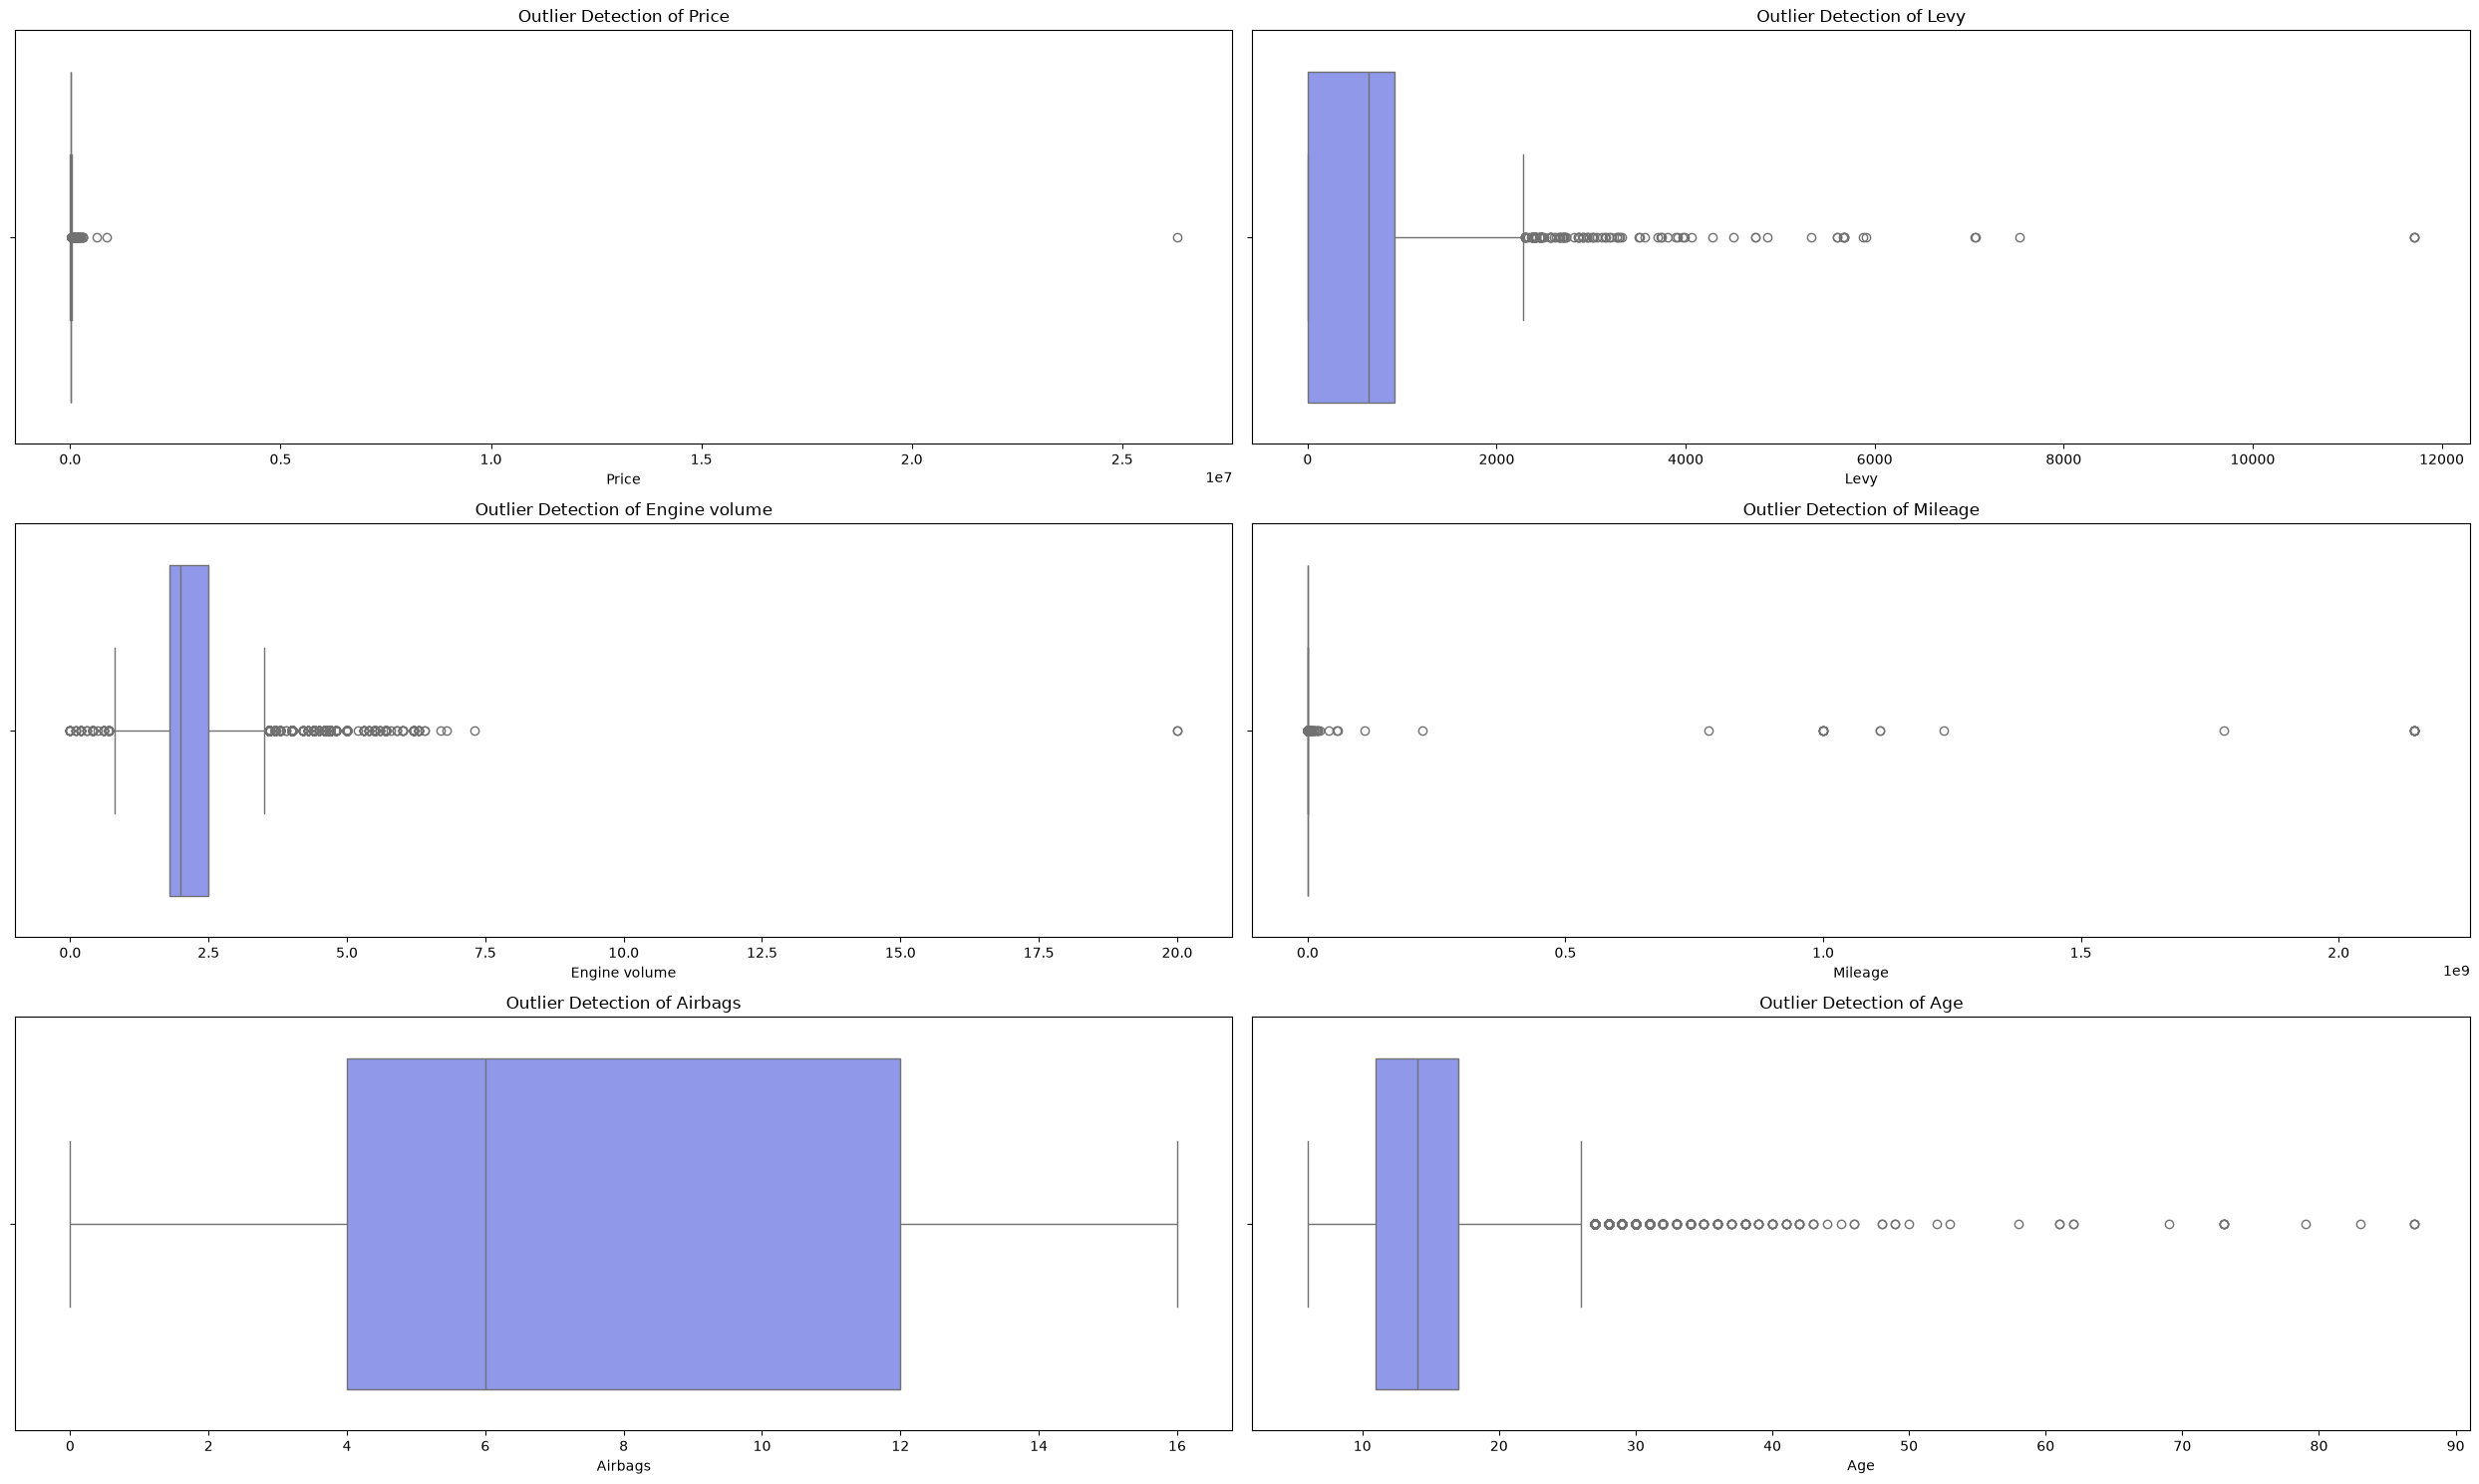

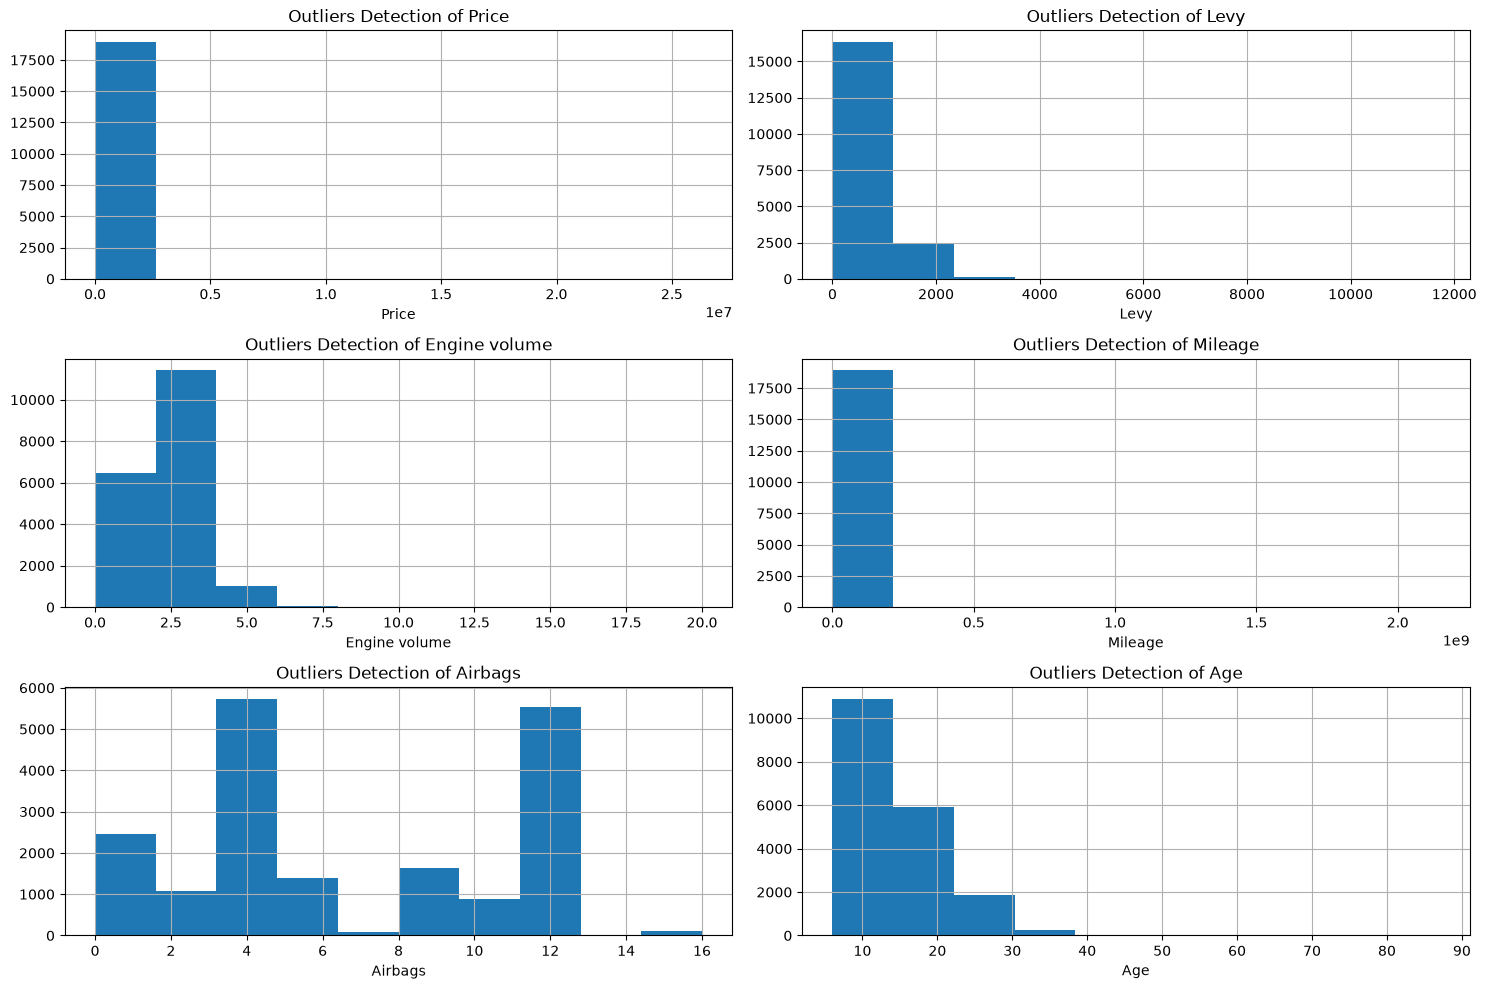

In [30]:
## Outlier Detection
numeric_feat = [var for var in data.columns if data[var].dtypes in ["int64", "float64"]]
plt.figure(figsize=(25, 15))

for i, col in enumerate(numeric_feat, 1):
    plt.subplot(math.ceil(len(numeric_feat)/2) , 2 , i)
    sns.boxplot(x=data[col], color="#818CF8")
    plt.title(f"Outlier Detection of {col}")
    
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_feat, 1):
    plt.subplot(math.ceil(len(numeric_feat)/2) , 2 , i)
    fig = data[col].hist(bins=10)
    fig.set_xlabel(col)
    fig.set_title(f"Outliers Detection of {col}")
    
plt.tight_layout()
plt.show()

In [31]:
## Outlier remove
def outlier_deletion(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    IQR = q3 - q1
    max_band = q3 + 1.5 * IQR
    min_band = q1 - 1.5 * IQR
    return data[(data[col] >= min_band) & (data[col] <= max_band)]

print(data.shape)
for col in numeric_feat:
    data = outlier_deletion(data, col)
print(data.shape)

(18924, 15)
(14743, 15)


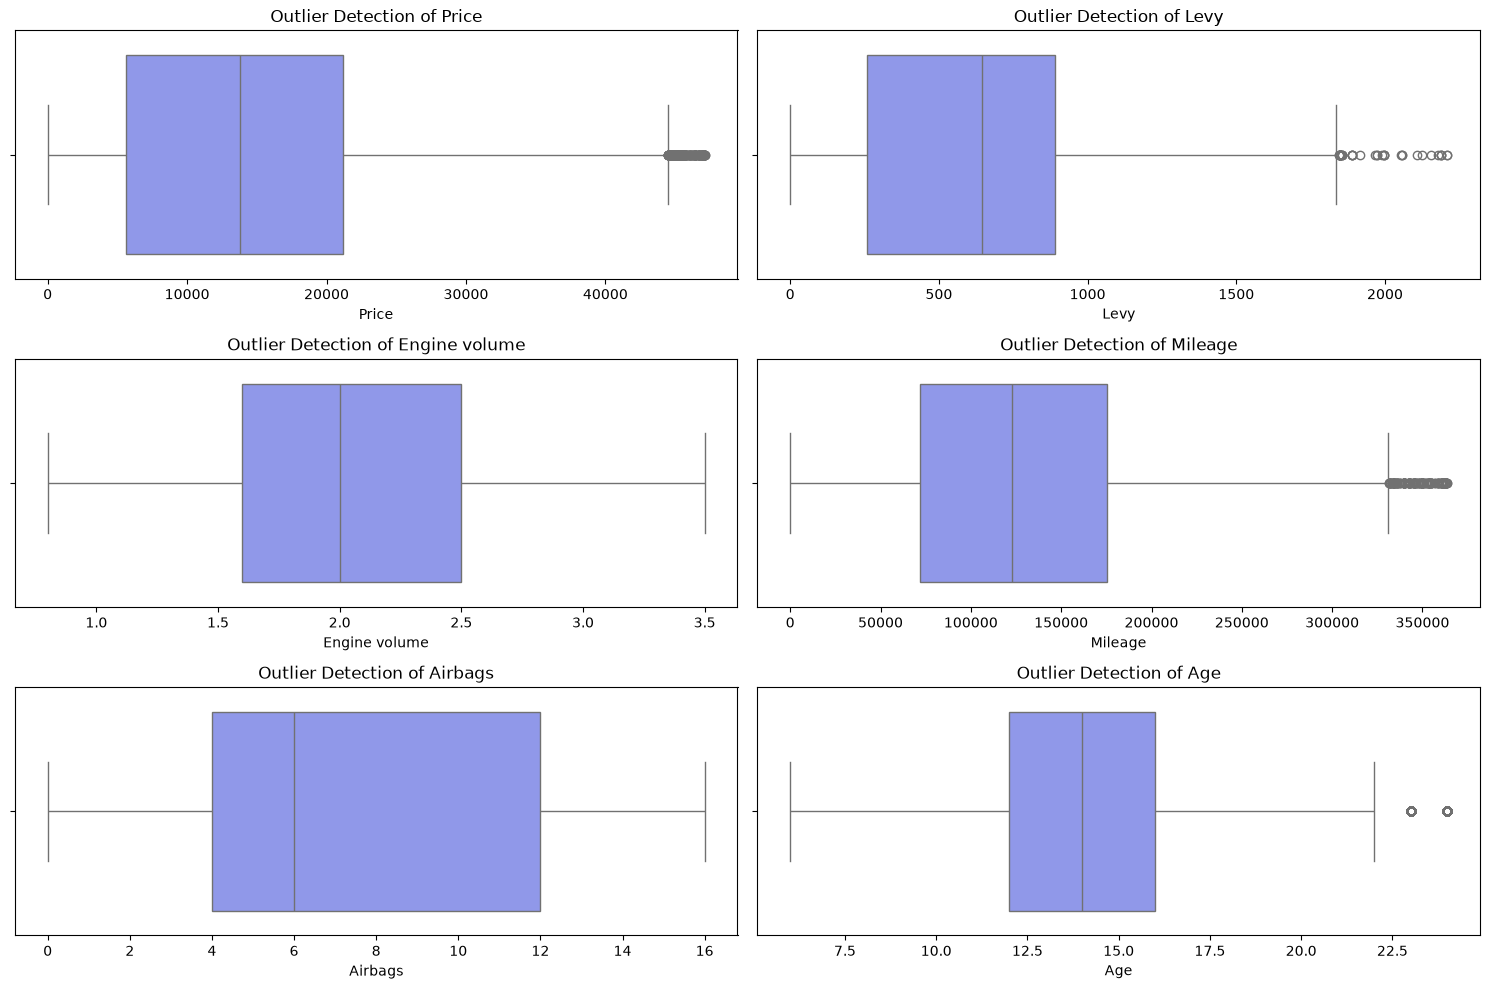

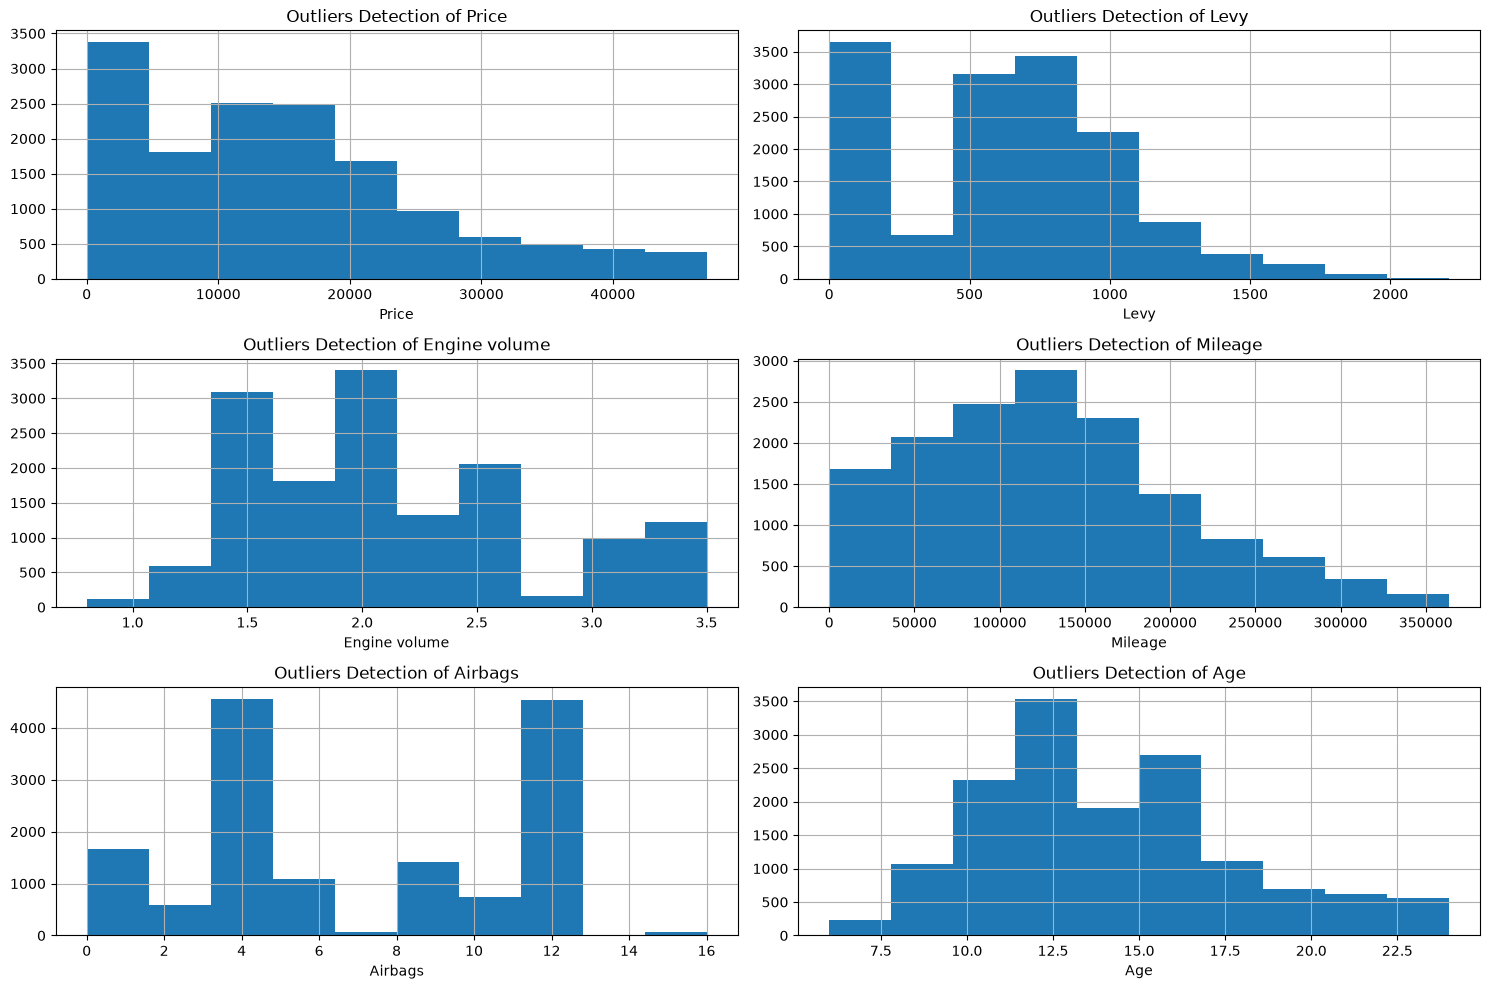

In [32]:
## Outlier Detection

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_feat, 1):
    plt.subplot(math.ceil(len(numeric_feat)/2) , 2 , i)
    sns.boxplot(x=data[col], color="#818CF8")
    plt.title(f"Outlier Detection of {col}")
    
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_feat, 1):
    plt.subplot(math.ceil(len(numeric_feat)/2) , 2 , i)
    fig = data[col].hist(bins=10)
    fig.set_xlabel(col)
    fig.set_title(f"Outliers Detection of {col}")
    
plt.tight_layout()
plt.show()

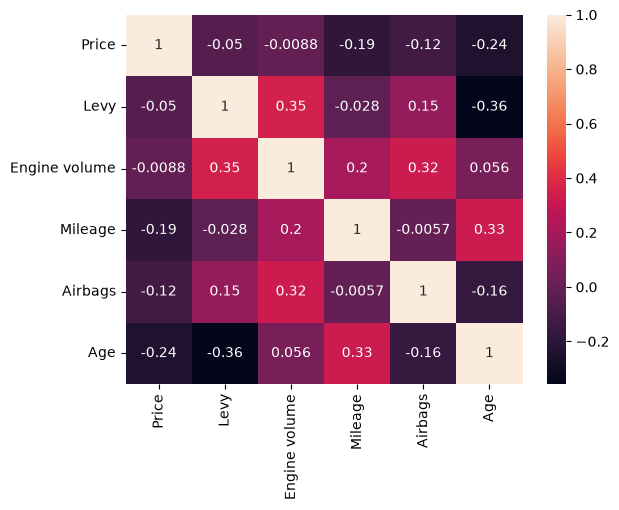

In [33]:
## Numerical Correlation
sns.heatmap(data.corr(numeric_only=True), annot=True)
plt.show()

In [34]:
data.Manufacturer.value_counts().head(15)

Manufacturer
TOYOTA           3192
HYUNDAI          3142
MERCEDES-BENZ    1291
CHEVROLET         977
HONDA             839
FORD              837
BMW               665
NISSAN            571
LEXUS             457
VOLKSWAGEN        433
SSANGYONG         415
KIA               409
SUBARU            243
AUDI              207
MITSUBISHI        174
Name: count, dtype: int64